In [1]:
# importing necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

In [3]:
# loading the dataset

In [4]:
df = pd.read_csv("water_potability.csv")

In [5]:
# displaying the 5 records of a dataset and knowing more about the data : the shape , columns , statistical values, description

In [6]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [7]:
df.shape

(3276, 10)

In [8]:
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [10]:
df.describe

<bound method NDFrame.describe of             ph    Hardness        Solids  Chloramines     Sulfate  \
0          NaN  204.890455  20791.318981     7.300212  368.516441   
1     3.716080  129.422921  18630.057858     6.635246         NaN   
2     8.099124  224.236259  19909.541732     9.275884         NaN   
3     8.316766  214.373394  22018.417441     8.059332  356.886136   
4     9.092223  181.101509  17978.986339     6.546600  310.135738   
...        ...         ...           ...          ...         ...   
3271  4.668102  193.681735  47580.991603     7.166639  359.948574   
3272  7.808856  193.553212  17329.802160     8.061362         NaN   
3273  9.419510  175.762646  33155.578218     7.350233         NaN   
3274  5.126763  230.603758  11983.869376     6.303357         NaN   
3275  7.874671  195.102299  17404.177061     7.509306         NaN   

      Conductivity  Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       564.308654       10.379783        86.990970   2.9631

In [11]:
# checking for null values
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [12]:
# total null values we have

In [13]:
df.isnull().sum().sum()

np.int64(1434)

In [14]:
# visualizing the null values and then filling up those nulls with median

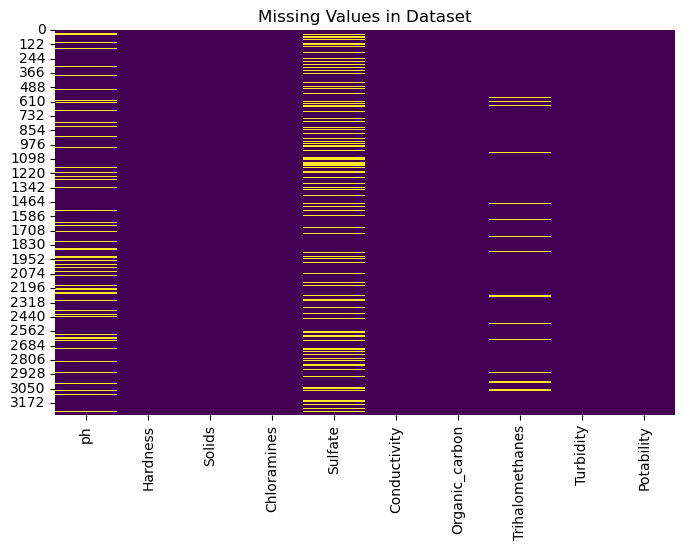

In [15]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values in Dataset")
plt.show()

In [16]:
df['ph'] = df['ph'].fillna(df['ph'].median())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].median())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].median())

In [17]:
# checking again if null exists

In [18]:
df.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [19]:
df.isnull().sum().sum()

np.int64(0)

In [20]:
# checking for any duplicacy of nay records

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.shape

(3276, 10)

In [23]:
# no null values are found and no duplicacy is there (data cleaning is done)

In [24]:
#EDA

In [25]:
# Check whether the dataset is balanced or imbalanced.

In [26]:
# Non-potable water samples are more than potable samples.
# Dataset is slightly imbalanced.

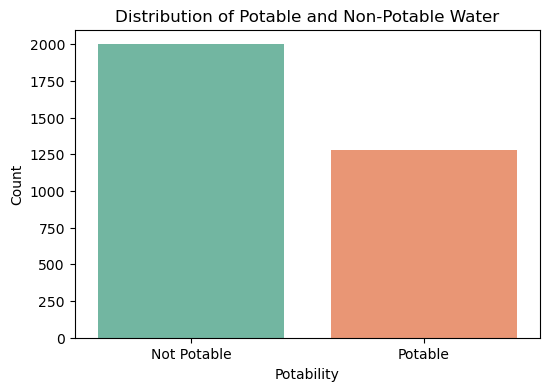

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Potability',
    hue='Potability',
    data=df,
    palette='Set2',
    legend=False
)

plt.title("Distribution of Potable and Non-Potable Water")
plt.xlabel("Potability")
plt.ylabel("Count")
plt.xticks([0,1],["Not Potable","Potable"])

plt.show()

In [28]:
# This directly shows which features are most associated with the target variable that is potability.
# It shows the correlation of all the features with potability

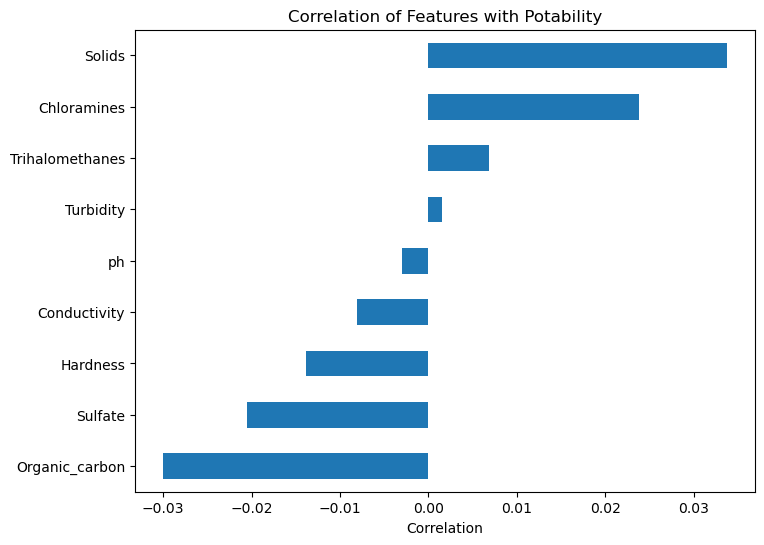

In [29]:
corr = df.corr(numeric_only=True)["Potability"].sort_values()

plt.figure(figsize=(8,6))

corr[:-1].plot(kind="barh")

plt.title("Correlation of Features with Potability")

plt.xlabel("Correlation")

plt.show()

In [30]:
corr = df.corr(numeric_only=True)['Potability'].sort_values(ascending=False)
print(corr)

Potability         1.000000
Solids             0.033743
Chloramines        0.023779
Trihalomethanes    0.006887
Turbidity          0.001581
ph                -0.003014
Conductivity      -0.008128
Hardness          -0.013837
Sulfate           -0.020476
Organic_carbon    -0.030001
Name: Potability, dtype: float64


In [31]:
# Histograms of Important Features
# Shows pairwise relationships of potability with the largest absolute correlations.

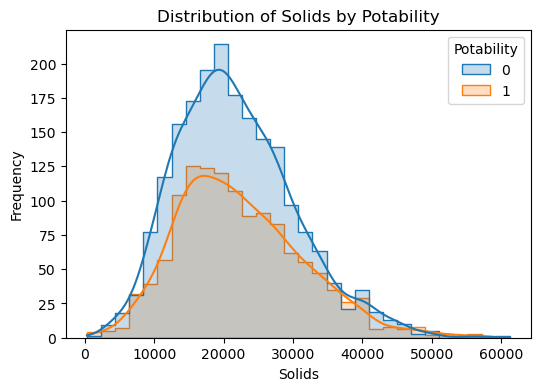

In [32]:
plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x="Solids",
    hue="Potability",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Distribution of Solids by Potability")
plt.xlabel("Solids")
plt.ylabel("Frequency")

plt.show()

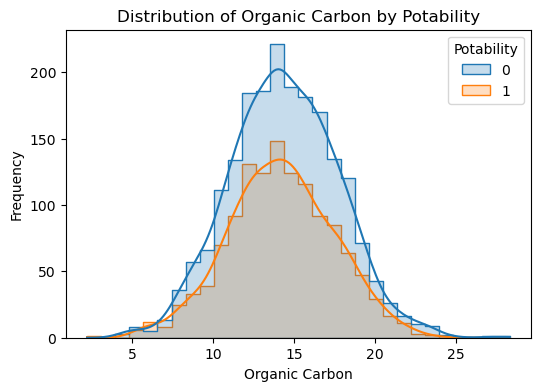

In [33]:
plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x="Organic_carbon",
    hue="Potability",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Distribution of Organic Carbon by Potability")
plt.xlabel("Organic Carbon")
plt.ylabel("Frequency")

plt.show()

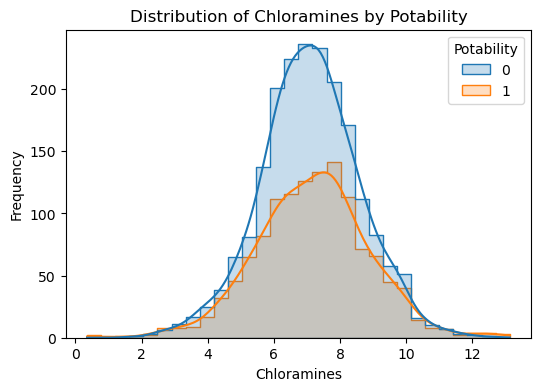

In [34]:
plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x="Chloramines",
    hue="Potability",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Distribution of Chloramines by Potability")
plt.xlabel("Chloramines")
plt.ylabel("Frequency")

plt.show()

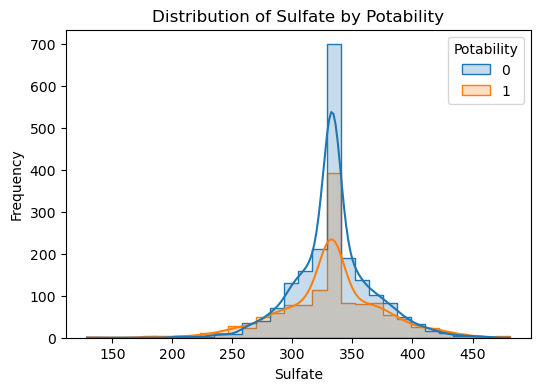

In [35]:
plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x="Sulfate",
    hue="Potability",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Distribution of Sulfate by Potability")
plt.xlabel("Sulfate")
plt.ylabel("Frequency")

plt.show()

In [36]:
# Feature Selection
# Separate Features and Target

In [37]:
X = df.drop("Potability", axis=1)
y = df["Potability"]

In [38]:
# Split the dataset into training and testing sets.
# 80% for training and 20% for testing.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
# Scale the Features

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
# Check the Shapes

In [43]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (2620, 9)
Testing Features: (656, 9)
Training Labels: (2620,)
Testing Labels: (656,)


In [44]:
#                                                            Training the Model

In [45]:
# Logistic Regression

In [46]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.6280487804878049


In [47]:
# Decision Tree

In [48]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.5762195121951219


In [49]:
# Random Forest

In [50]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.6737804878048781


In [51]:
# K-Nearest Neighbors(KNN)

In [52]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.6280487804878049


In [53]:
# Comparing the accuracy of all the models

In [54]:
results = {
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "KNN": accuracy_score(y_test, knn_pred)
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.6280
Decision Tree: 0.5762
Random Forest: 0.6738
KNN: 0.6280


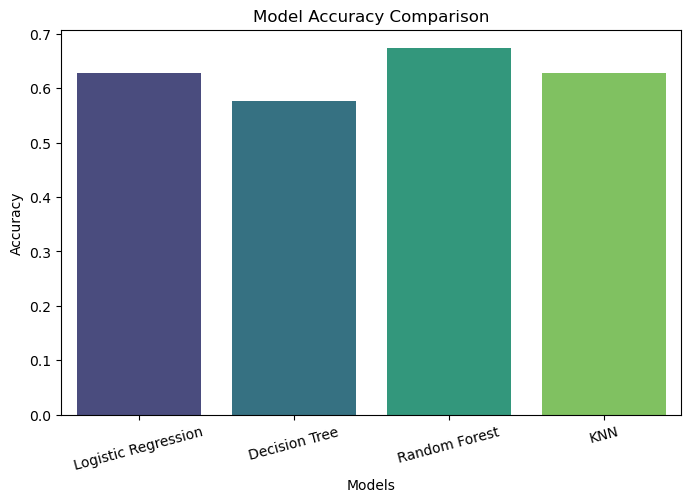

In [64]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=list(results.keys()),
    y=list(results.values()),
    hue=list(results.keys()),
    palette="viridis",
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.xticks(rotation=15)

plt.show()

In [57]:
# Evaluating the model

In [58]:
best_model = rf

              precision    recall  f1-score   support

           0       0.70      0.85      0.77       412
           1       0.60      0.38      0.46       244

    accuracy                           0.67       656
   macro avg       0.65      0.61      0.61       656
weighted avg       0.66      0.67      0.65       656



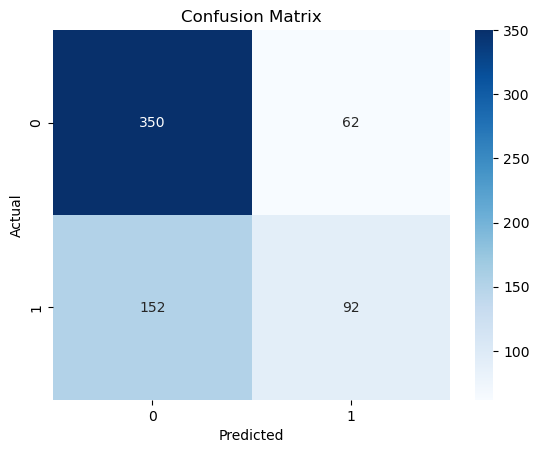

In [59]:
best_pred = best_model.predict(X_test)

print(classification_report(y_test, best_pred))

cm = confusion_matrix(y_test, best_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [60]:
import joblib

joblib.dump(best_model, "water_potability_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [61]:
# Testing the sample inputs

In [62]:
sample = [[7.2, 180, 21000, 7.5, 320, 420, 12.5, 70, 4.5]]

sample_scaled = scaler.transform(sample)

prediction = best_model.predict(sample_scaled)

if prediction[0] == 1:
    print("Water is Potable")
else:
    print("Water is Not Potable")

Water is Not Potable


C:\Users\HP\anaconda3\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
